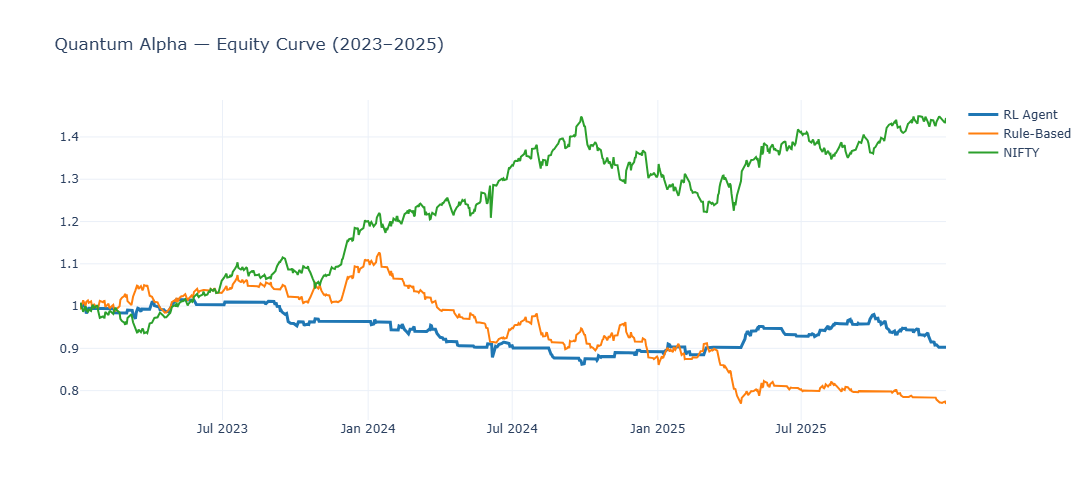

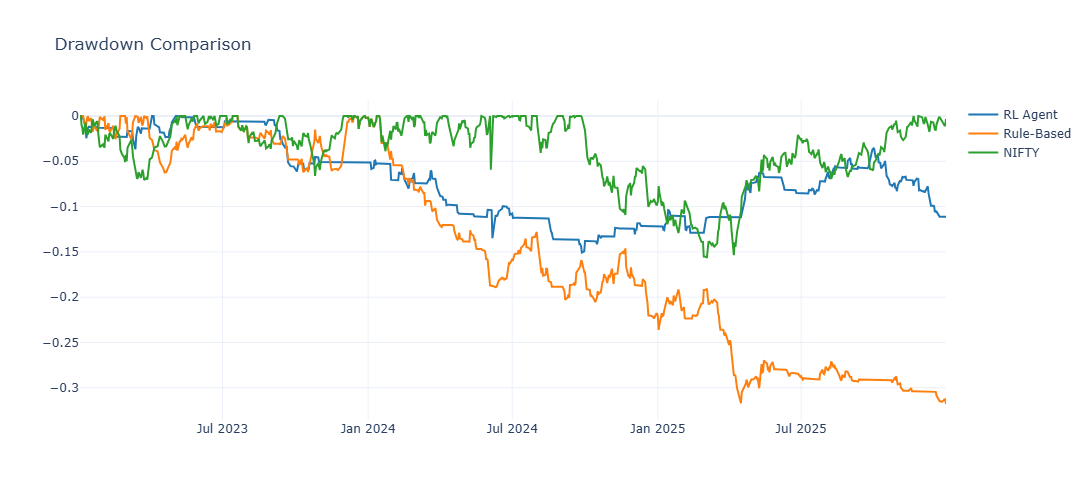

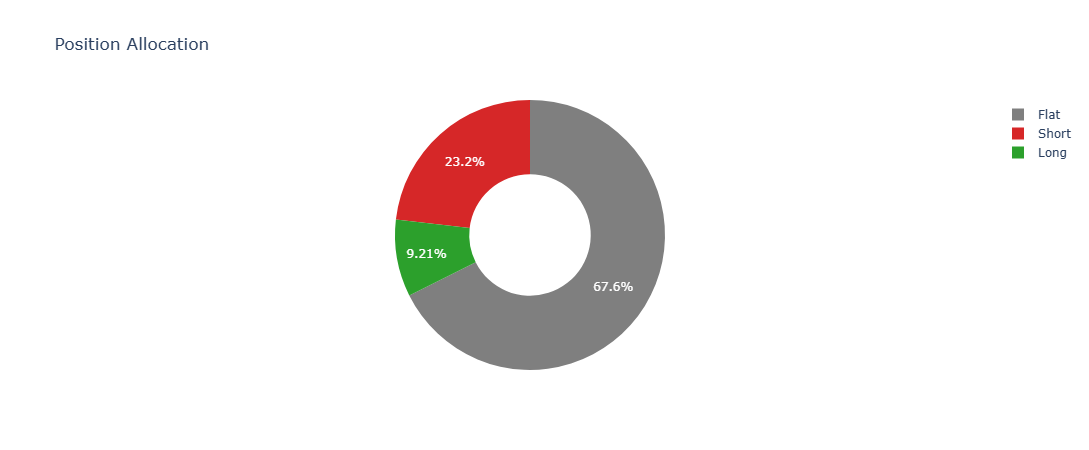

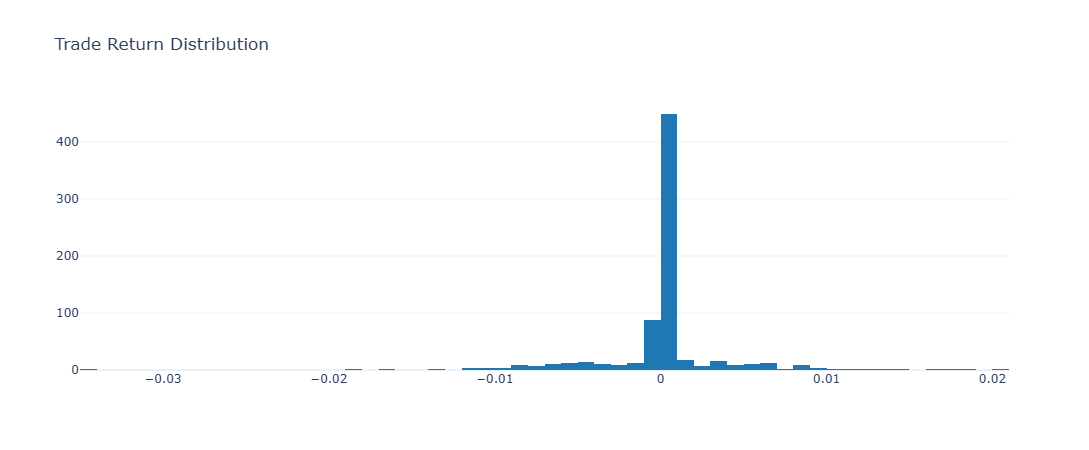

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. FINAL MODEL
class DQN(nn.Module):
    def __init__(self, state_size=7, action_size=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_size, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 64),  nn.ReLU(),
            nn.Linear(64, action_size)
        )
    def forward(self, x):
        return self.net(x)

policy_net = DQN().to(device)
policy_net.load_state_dict(torch.load("../models/quantum_alpha_final.pth", map_location=device))
policy_net.eval()

# 2. ENVIRONMENT
class QuantumAlphaEnv:
    def __init__(self, data):
        self.data = data.reset_index(drop=True)
        self.feature_cols = ["mom_20_norm", "vol_signal_norm", "trend_signal_norm",
                             "dd_signal_norm", "vix_signal_norm", "breadth_signal_norm"]
        self.max_steps = len(self.data) - 1
        self.reset()
   
    def reset(self):
        self.current_step = 0
        self.position = 0
        self.balance = 1.0
        return self._get_observation()
   
    def _get_observation(self):
        row = self.data.iloc[self.current_step]
        obs = row[self.feature_cols].values.astype(np.float32)
        return np.append(obs, self.position)
   
    def step(self, action):
        prev_position = self.position
        new_position = {0: 0, 1: 1, 2: -1}[action]
        ret = self.data.iloc[self.current_step]["nifty_ret"]
        cost = abs(new_position - prev_position) * 0.0005
        net_ret = prev_position * ret - cost
        self.balance *= (1 + net_ret)
        self.position = new_position
        self.current_step += 1
        done = self.current_step >= self.max_steps
        return self._get_observation(), net_ret, done, {"net_ret": net_ret, "position": self.position}

# 3. RUN AGENT
test_data = pd.read_csv("../data/state_dataset.csv", index_col="Date", parse_dates=True)
test_data = test_data.join(pd.read_csv("../data/market_master.csv", index_col="Date", parse_dates=True)[["nifty_ret"]])
test_data = test_data.loc["2023":"2025"]

env = QuantumAlphaEnv(test_data)
state = env.reset()
done = False
equity = 1.0
equity_curve = [1.0]
returns = []
positions = []

while not done:
    with torch.no_grad():
        s = torch.FloatTensor(state).unsqueeze(0).to(device)
        action = policy_net(s).argmax().item()
    next_state, _, done, info = env.step(action)
    equity *= (1 + info["net_ret"])
    equity_curve.append(equity)
    returns.append(info["net_ret"])
    positions.append(info["position"])
    state = next_state

rl_equity = np.array(equity_curve)
rl_returns = np.array(returns)
pos = np.array(positions)

rule = pd.read_csv("../backtesting/market_backtest_v7.csv", index_col=0)
rule.index = pd.to_datetime(rule.index)
rule = rule.loc["2023":"2025"]
rule_equity = (1 + rule["strategy_ret_v2"]).cumprod().values
nifty_equity = (1 + test_data["nifty_ret"]).cumprod().values

# Metrics
sharpe = (np.mean(rl_returns) - 0.065/252) / (np.std(rl_returns) + 1e-8) * np.sqrt(252)
cagr = rl_equity[-1] ** (252 / len(rl_returns)) - 1
max_dd = (rl_equity / np.maximum.accumulate(rl_equity) - 1).min()

# =============================================
# FIGURE 1: Equity + Drawdown
# =============================================
fig1 = go.Figure()
fig1.add_trace(go.Scatter(x=test_data.index, y=rl_equity, name="RL Agent", line=dict(color="#1f77b4", width=3)))
fig1.add_trace(go.Scatter(x=test_data.index, y=rule_equity[:len(rl_equity)], name="Rule-Based", line=dict(color="#ff7f0e", width=2)))
fig1.add_trace(go.Scatter(x=test_data.index, y=nifty_equity[:len(rl_equity)], name="NIFTY", line=dict(color="#2ca02c", width=2)))
fig1.update_layout(title="Quantum Alpha — Equity Curve (2023–2025)", height=500, template="plotly_white")
fig1.show()

fig_dd = go.Figure()
dd_rl = rl_equity / np.maximum.accumulate(rl_equity) - 1
dd_rule = rule_equity / np.maximum.accumulate(rule_equity) - 1
dd_nifty = nifty_equity / np.maximum.accumulate(nifty_equity) - 1
fig_dd.add_trace(go.Scatter(x=test_data.index, y=dd_rl, name="RL Agent", line=dict(color="#1f77b4")))
fig_dd.add_trace(go.Scatter(x=test_data.index, y=dd_rule[:len(dd_rl)], name="Rule-Based", line=dict(color="#ff7f0e")))
fig_dd.add_trace(go.Scatter(x=test_data.index, y=dd_nifty[:len(dd_rl)], name="NIFTY", line=dict(color="#2ca02c")))
fig_dd.update_layout(title="Drawdown Comparison", height=500, template="plotly_white")
fig_dd.show()

# =============================================
# FIGURE 2: Position + Trade Analysis
# =============================================
fig2 = go.Figure()

# Pie chart (separate figure)
labels = ["Long", "Short", "Flat"]
values = [(pos == 1).mean()*100, (pos == -1).mean()*100, (pos == 0).mean()*100]
pie = go.Pie(labels=labels, values=values, hole=0.45, marker_colors=["#2ca02c", "#d62728", "#7f7f7f"])
fig2.add_trace(pie)
fig2.update_layout(title="Position Allocation", height=450, template="plotly_white")
fig2.show()

# Histogram (separate figure)
hist = go.Figure()
hist.add_trace(go.Histogram(x=rl_returns, nbinsx=60, marker_color="#1f77b4"))
hist.update_layout(title="Trade Return Distribution", height=450, template="plotly_white")
hist.show()